In [151]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

N_PEERS = 300
N_ITERS = 5
T_END = 300
TARGET_DISCOVERY_RATE = 99

In [152]:
def read_data(target: str) -> list[list[tuple[float, float]]]:
    data = []
    for i in range(N_ITERS):
        with open(f'../scale/{target}/{N_PEERS}/r_{i}.txt', 'r') as f:
            time_init = 0
            measurements = []
            
            for line in f:
                parts = line.strip().split()
                if parts[1] == 'N/A':
                    continue

                time = int(parts[0])
                if time_init == 0:
                    time_init = time
                execution_time = (time - time_init) / 1000
                reachability = float(parts[1])
                
                measurements.append((execution_time, reachability * 100))
            data.append(measurements)
    return data

In [153]:
def time_split_discovery_time(data: list[tuple[float, float]]) -> list[float]:
    result = []
    time_now = 0.1
    split_discovery_time = 0.0
    for time, reach in data:
        if time >= time_now + 10:
            time_now += 10
            if split_discovery_time == 0.0:
                result.append(10.0)
            else:
                result.append(split_discovery_time)
                
            split_discovery_time = 0.0
            continue

        if reach > TARGET_DISCOVERY_RATE and split_discovery_time == 0.0:
            split_discovery_time = time - time_now + 0.1
    return result
        

In [154]:
def parse_all_seeds(target: str) -> tuple[list[int], list[list[float]]]:
    dt_flow_seeds = [time_split_discovery_time(data) for data in read_data(target)]
    min_length = min([len(n) for n in dt_flow_seeds])
    
    result = []
    for i in range(min_length):
        result.append([n[i] for n in dt_flow_seeds])
    return [10 * (i+1) for i in range(min_length)], result

In [155]:
def draw(targets: list[str]):
    fig, ax = plt.subplots(figsize=(9, 5))

    palette = [
        ['#cde4f5', '#185FA5', '#378ADD'],
        ['#f5cdcd', '#a51818', '#dd3737'],
        ['#cdf5d6', '#18a558', '#37dd7a'],
        ['#eadcf8', '#5a189a', '#c77dff']
    ]

    for idx, target in enumerate(targets):
        size_growth, reaches = parse_all_seeds(target)

        # Draw box plots
        bp = ax.boxplot(reaches, labels=[str(v) for v in size_growth], patch_artist=True,
                        boxprops=dict(facecolor=palette[idx][0], color=palette[idx][1]),
                        medianprops=dict(color=palette[idx][1], linewidth=2),
                        whiskerprops=dict(color=palette[idx][1]),
                        capprops=dict(color=palette[idx][1]),
                        flierprops=dict(markerfacecolor=palette[idx][2], marker='o',
                                    markersize=4, alpha=1), 
                        widths=0.18,
                        positions=[1 + i + 0.2 * (idx - 1) for i in range(len(size_growth))], 
                        )
        
        if idx != 2:
            ax.set_xticklabels([])
            ax.set_xlabel(None)
            ax.tick_params(bottom=False)

        # Compute medians and connect with a line
        medians = [np.median(d) for d in reaches]
        x_positions=[1 + i + 0.2 * (idx - 1) for i in range(len(size_growth))]

        ax.plot(x_positions, medians,
                color=palette[idx][1], marker='.', linewidth=1,
                markersize=3, zorder=5)

    # Create legend handles
    legend_labels = ['c-s', 'trickle', 'ours']
    legend_handles = [mpatches.Patch(color=palette[i][1], label=legend_labels[i]) 
                      for i in range(len(targets))]

    ax.set_xlabel('Number of Peers')
    ax.set_ylabel('>99% Peer discovery time (sec)')
    ax.legend(handles=legend_handles, loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.ylim(0, 5)
    plt.tight_layout()
    plt.savefig(f'scale_discovery_time_cmp.jpg', dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_4053292/3354472649.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(reaches, labels=[str(v) for v in size_growth], patch_artist=True,
/tmp/ipykernel_4053292/3354472649.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(reaches, labels=[str(v) for v in size_growth], patch_artist=True,
/tmp/ipykernel_4053292/3354472649.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(reaches, labels=[str(v) for v in size_growth], patch_artist=True,


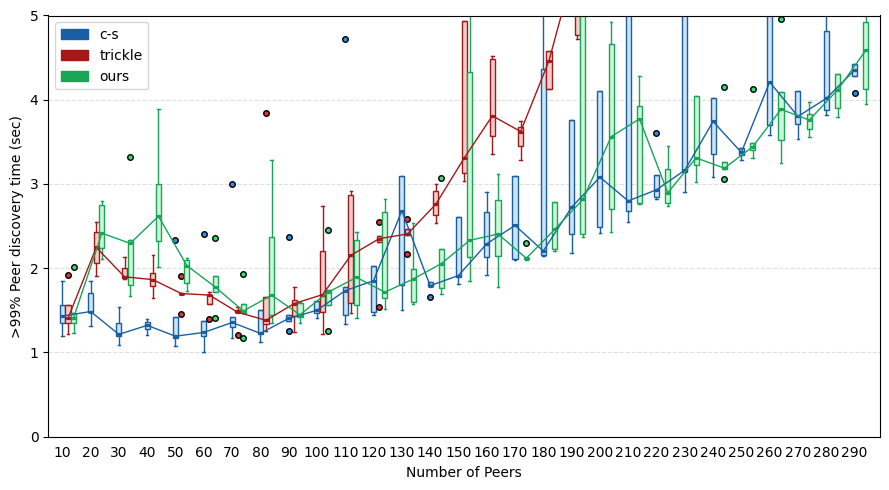

In [156]:
draw(['client-server', 'dev-eval-trickle', 'dev-v2'])